🔍 Traitement du split 'train' (1120 fichiers)...
🔍 Traitement du split 'val' (226 fichiers)...
🔍 Traitement du split 'test' (134 fichiers)...

📊 BILAN GLOBAL DATASET (TRAIN + VAL + TEST)
• Nombre total d'objets annotés : 4233
• Surface totale de plastique   : 113.072 m²

--- 1. STATISTIQUES GLOBALES PAR CLASSE ---
                    Classe Nb Items % Items Surf. (m²) % Surf. Moy. (cm²) Méd. (cm²)
           Mousse expansée     1723   40.7%     17.179   15.2%       99.7       51.6
Fragments plastique rigide      739   17.5%     17.088   15.1%      231.2      124.3
                   Cordage      551   13.0%     38.015   33.6%      689.9      215.8
             bouteille PET      205    4.8%      4.224    3.7%      206.0      177.7
               Petit bidon      185    4.4%      9.263    8.2%      500.7      385.5
            Bouées pieuvre      139    3.3%      1.901    1.7%      136.7      118.5
    Plastique souple (sac)      135    3.2%      5.575    4.9%      413.0      316.5
    

<Figure size 1400x600 with 0 Axes>

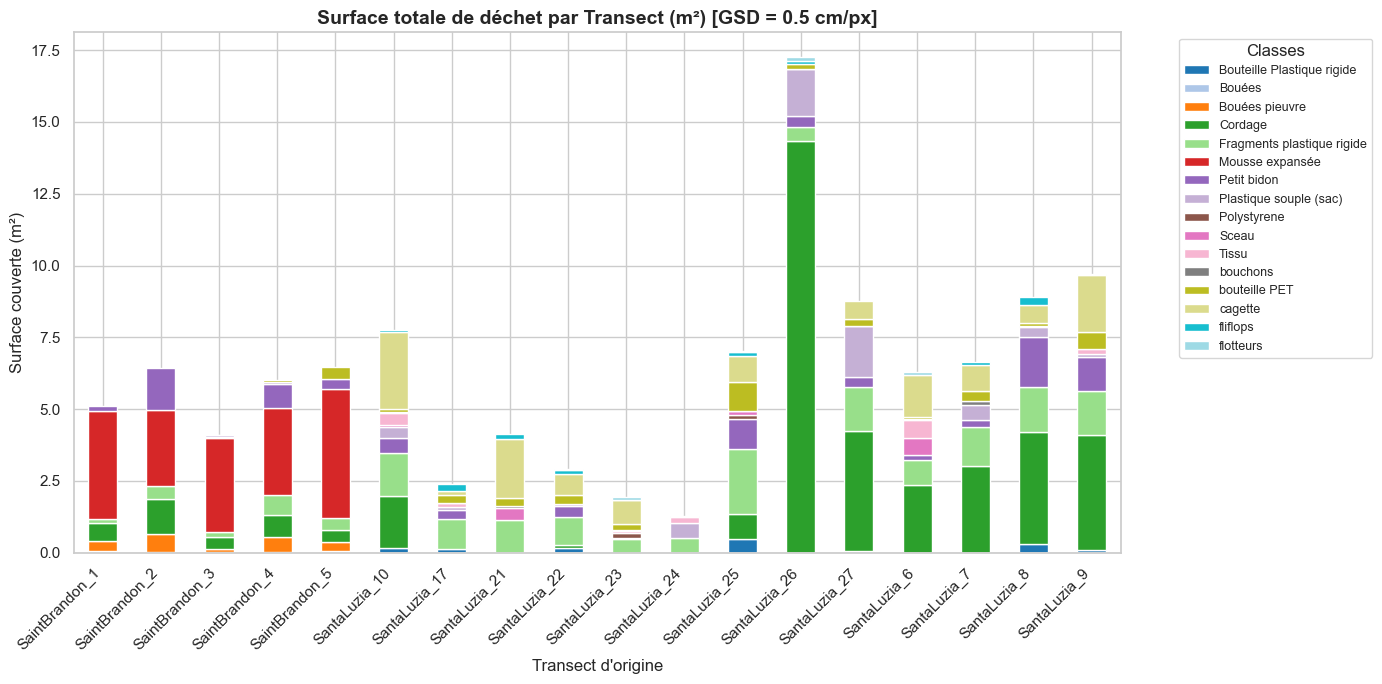

In [7]:
import re
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from shapely.geometry import Polygon

# --- 1. CONFIGURATION ---
CLASS_NAMES = {
    0: "bouteille PET",
    1: "Cordage",
    2: "Bouées",
    3: "Inconnu",
    4: "Fragments plastique rigide",
    5: "Bouées pieuvre",
    6: "Petit bidon",
    7: "Plastique souple (sac)",
    8: "Mousse expansée",
    9: "Sceau",
    10: "Polystyrene",
    11: "fliflops",
    12: "casques",
    13: "bouchons",
    14: "cagette",
    15: "Bouteille Plastique rigide",
    16: "Morceaux de bois",
    17: "Verre",
    18: "Tissu",
    19: "flotteurs",
}

# Dimensions des tuiles (en pixels)
TILE_WIDTH = 640
TILE_HEIGHT = 640

# --- RESOLUTION SPATIALE (GSD) ---
# ⚠️ MODIFIEZ CETTE VALEUR SELON VOTRE ACQUISITION DRONE
GSD_CM_PER_PX = 0.5  # Exemple : 1 px = 0.5 cm
PX2_TO_CM2 = GSD_CM_PER_PX**2  # 1 px² = 0.25 cm²
CM2_TO_M2 = 1 / 10000  # 1 m² = 10 000 cm²

# Chemin d'accès au dataset
DATASET_ROOT = Path(r"E:\PixelOdyssey\3. Processed dataset\processed_dataset")


def extract_transect_name(filename: str) -> str:
    """Extrait le nom du transect et le simplifie sous la forme :

    'SaintBrandon_N' ou 'SantaLuzia_N'
    """
    stem = filename.split(".")[0]

    # --- 1. CAS SAINT BRANDON (SB / StBrandon) ---
    # Recherche du numéro après 'StBrandonTransect_' ou 'SB_'
    sb_match = re.search(r"StBrandonTransect_(\d+)", stem, re.IGNORECASE)
    if sb_match:
        return f"SaintBrandon_{sb_match.group(1)}"

    # --- 2. CAS SANTA LUZIA (SL / transect) ---
    # Recherche du numéro après 'transect'
    sl_match = re.search(r"transect_?(\d+)", stem, re.IGNORECASE)
    if sl_match:
        return f"SantaLuzia_{sl_match.group(1)}"

    # --- 3. SECOURS (Si aucun motif ne matche) ---
    # Si c'est un SL non capturé
    if stem.startswith("SL"):
        return "SantaLuzia_Inconnu"
    elif stem.startswith("SB"):
        return "SaintBrandon_Inconnu"

    return "Transect_Inconnu"


# --- 2. EXTRACTION ET ANALYSE ---
def parse_all_labels(dataset_root: Path, tile_w: int, tile_h: int):
    records = []
    splits = ["train", "val", "test"]

    for split in splits:
        labels_dir = dataset_root / "labels" / split
        if not labels_dir.exists():
            continue

        txt_files = list(labels_dir.glob("*.txt"))
        print(f"🔍 Traitement du split '{split}' ({len(txt_files)} fichiers)...")

        for txt_file in txt_files:
            transect_name = extract_transect_name(txt_file.name)

            with open(txt_file, "r") as f:
                lines = f.readlines()

            for line in lines:
                parts = line.strip().split()
                if len(parts) < 7:  # Moins de 3 points
                    continue

                class_id = int(parts[0])
                coords = np.array([float(x) for x in parts[1:]]).reshape(-1, 2)

                # Dénormalisation en pixels
                coords[:, 0] *= tile_w
                coords[:, 1] *= tile_h

                poly = Polygon(coords)

                if poly.is_valid and poly.area > 0:
                    area_px = poly.area
                    area_cm2 = area_px * PX2_TO_CM2

                    records.append(
                        {
                            "split": split,
                            "file": txt_file.name,
                            "transect": transect_name,
                            "class_id": class_id,
                            "class_name": CLASS_NAMES.get(
                                class_id, f"Classe_{class_id}"
                            ),
                            "area_px": area_px,
                            "area_cm2": area_cm2,
                        }
                    )

    return pd.DataFrame(records)


# Execution
df = parse_all_labels(DATASET_ROOT, TILE_WIDTH, TILE_HEIGHT)

if df.empty:
    print("❌ Aucun label trouvé.")
else:
    # Total du plastique sur l'ensemble du dataset
    total_dataset_items = len(df)
    total_dataset_area_m2 = df["area_cm2"].sum() * CM2_TO_M2

    print(f"\n==================================================")
    print(f"📊 BILAN GLOBAL DATASET (TRAIN + VAL + TEST)")
    print(f"==================================================")
    print(f"• Nombre total d'objets annotés : {total_dataset_items}")
    print(f"• Surface totale de plastique   : {total_dataset_area_m2:.3f} m²")

    # --- 3. STATISTIQUES GLOBALES PAR CLASSE ---
    global_stats = (
        df.groupby(["class_id", "class_name"])
        .agg(
            nb_items=("area_cm2", "count"),
            surface_totale_m2=("area_cm2", lambda x: x.sum() * CM2_TO_M2),
            taille_moyenne_cm2=("area_cm2", "mean"),
            taille_mediane_cm2=("area_cm2", "median"),
        )
        .reset_index()
    )

    global_stats["prop_items_pct"] = (
        global_stats["nb_items"] / total_dataset_items
    ) * 100
    global_stats["prop_surface_pct"] = (
        global_stats["surface_totale_m2"] / total_dataset_area_m2
    ) * 100
    global_stats = global_stats.sort_values(by="nb_items", ascending=False)

    print("\n--- 1. STATISTIQUES GLOBALES PAR CLASSE ---")
    print(
        global_stats[
            [
                "class_name",
                "nb_items",
                "prop_items_pct",
                "surface_totale_m2",
                "prop_surface_pct",
                "taille_moyenne_cm2",
                "taille_mediane_cm2",
            ]
        ].to_string(
            index=False,
            header=[
                "Classe",
                "Nb Items",
                "% Items",
                "Surf. (m²)",
                "% Surf.",
                "Moy. (cm²)",
                "Méd. (cm²)",
            ],
            formatters={
                "prop_items_pct": "{:.1f}%".format,
                "prop_surface_pct": "{:.1f}%".format,
                "surface_totale_m2": "{:.3f}".format,
                "taille_moyenne_cm2": "{:.1f}".format,
                "taille_mediane_cm2": "{:.1f}".format,
            },
        )
    )

    # --- 4. STATISTIQUES DÉTAILLÉES PAR TRANSECT ---
    transect_stats = (
        df.groupby(["transect", "class_name"])
        .agg(
            nb_items=("area_cm2", "count"),
            surface_totale_m2=("area_cm2", lambda x: x.sum() * CM2_TO_M2),
            taille_mediane_cm2=("area_cm2", "median"),
        )
        .reset_index()
    )

    # Calcul des totaux par transect
    transect_totals = (
        df.groupby("transect")
        .agg(
            tot_items_transect=("area_cm2", "count"),
            tot_surf_transect_m2=("area_cm2", lambda x: x.sum() * CM2_TO_M2),
        )
        .reset_index()
    )

    transect_stats = pd.merge(
        transect_stats, transect_totals, on="transect", how="left"
    )
    transect_stats["prop_items_du_transect_pct"] = (
        transect_stats["nb_items"] / transect_stats["tot_items_transect"]
    ) * 100
    transect_stats["prop_surf_du_transect_pct"] = (
        transect_stats["surface_totale_m2"]
        / transect_stats["tot_surf_transect_m2"]
    ) * 100

    print("\n--- 2. APERÇU PAR TRANSECT (Extrait des 15 premières lignes) ---")
    print(
        transect_stats[
            [
                "transect",
                "class_name",
                "nb_items",
                "prop_items_du_transect_pct",
                "surface_totale_m2",
                "prop_surf_du_transect_pct",
            ]
        ]
        .head(15)
        .to_string(
            index=False,
            header=[
                "Transect",
                "Classe",
                "Items",
                "% Items Trans.",
                "Surf. (m²)",
                "% Surf. Trans.",
            ],
            formatters={
                "prop_items_du_transect_pct": "{:.1f}%".format,
                "prop_surf_du_transect_pct": "{:.1f}%".format,
                "surface_totale_m2": "{:.3f}".format,
            },
        )
    )

    # --- 5. EXPORT DES RÉSULTATS ---
    output_dir = DATASET_ROOT.parent / "stats_exports"
    output_dir.mkdir(exist_ok=True)

    global_stats.to_csv(
        output_dir / "stats_globales_classes.csv", index=False, encoding="utf-8"
    )
    transect_stats.to_csv(
        output_dir / "stats_par_transect.csv", index=False, encoding="utf-8"
    )
    print(
        f"\n💾 Fichiers CSV exportés avec succès dans : {output_dir.resolve()}"
    )

    # --- 6. VISUALISATION GRAPHIQUE PAR TRANSECT ---
    plt.figure(figsize=(14, 6))
    sns.set_theme(style="whitegrid")

    # Graphique en barres empilées de la surface de plastique par transect
    pivot_surf = transect_stats.pivot(
        index="transect", columns="class_name", values="surface_totale_m2"
    ).fillna(0)
    ax = pivot_surf.plot(
        kind="bar", stacked=True, figsize=(14, 7), colormap="tab20"
    )

    plt.title(
        f"Surface totale de déchet par Transect (m²) [GSD = {GSD_CM_PER_PX} cm/px]",
        fontsize=14,
        fontweight="bold",
    )
    plt.xlabel("Transect d'origine")
    plt.ylabel("Surface couverte (m²)")
    plt.legend(
        title="Classes", bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=9
    )
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

🔍 Traitement du split 'train' (13 fichiers)...
🚫 150 item(s) exclu(s) de l'analyse (classes exclues : ['Morceaux de bois']).

📊 BILAN GLOBAL DATASET (TRAIN + VAL + TEST)
• Nombre total d'objets annotés : 1200
• Surface totale de plastique   : 37.280 m²

--- 1. STATISTIQUES GLOBALES PAR CLASSE ---
                    Classe Nb Items % Items Surf. (m²) % Surf. Moy. (cm²) Méd. (cm²)
                   Inconnu      626   52.2%      8.095   21.7%      129.3       60.1
Fragments plastique rigide      195   16.2%      5.315   14.3%      272.6      121.7
                   Cordage       90    7.5%     11.720   31.4%     1302.3      397.0
             bouteille PET       64    5.3%      1.281    3.4%      200.1      200.3
                  bouchons       40    3.3%      0.120    0.3%       29.9       24.8
    Plastique souple (sac)       39    3.2%      1.998    5.4%      512.3      364.1
               Petit bidon       39    3.2%      2.400    6.4%      615.5      511.0
Bouteille Plastique ri

<Figure size 1400x600 with 0 Axes>

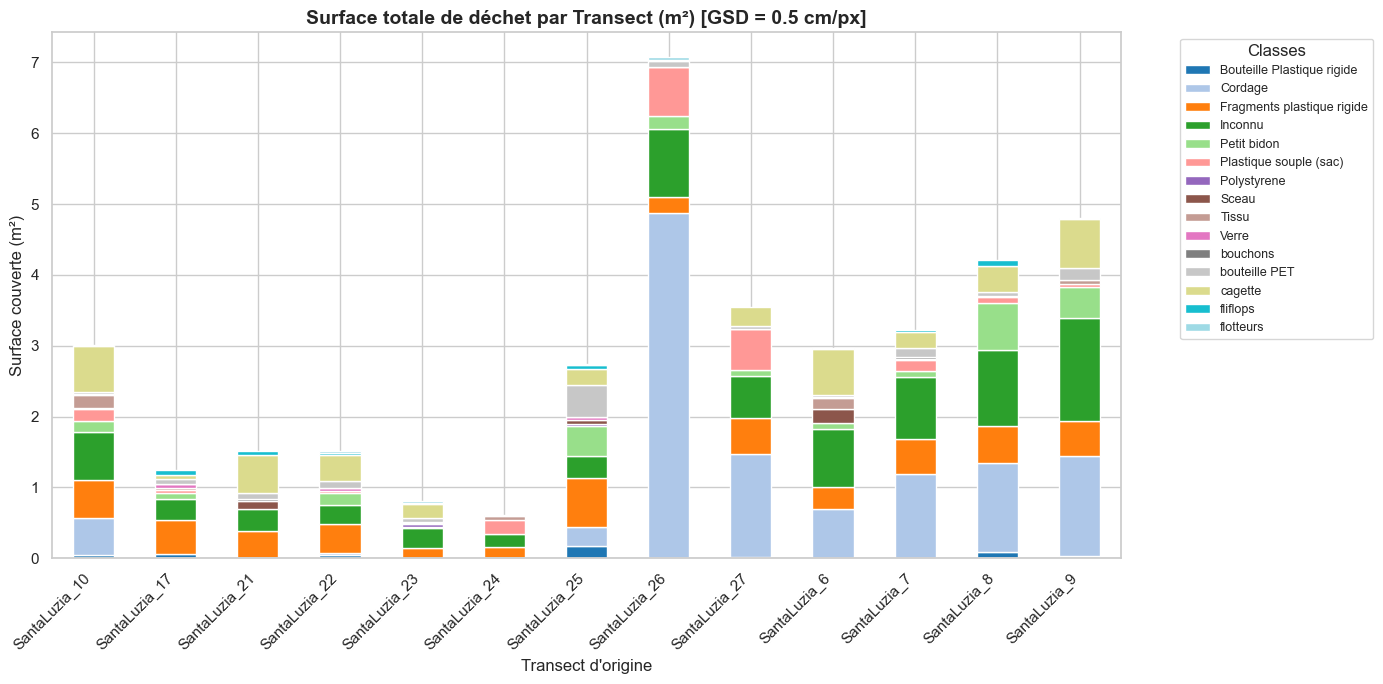

: 

In [ ]:
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from PIL import Image
from shapely.geometry import Polygon

# --- 1. CONFIGURATION ---
CLASS_NAMES = {
    0: "bouteille PET",
    1: "Cordage",
    2: "Bouées",
    3: "Inconnu",
    4: "Fragments plastique rigide",
    5: "Bouées pieuvre",
    6: "Petit bidon",
    7: "Plastique souple (sac)",
    8: "Mousse expansée",
    9: "Sceau",
    10: "Polystyrene",
    11: "fliflops",
    12: "casques",
    13: "bouchons",
    14: "cagette",
    15: "Bouteille Plastique rigide",
    16: "Morceaux de bois",
    17: "Verre",
    18: "Tissu",
    19: "flotteurs",
}

# Classes à exclure de l'analyse (par nom, tel que défini dans CLASS_NAMES ci-dessus).
# Ces items seront retirés AVANT le calcul de toutes les stats (comptes, surfaces,
# pourcentages) : ils ne comptent donc ni dans le numérateur ni dans le dénominateur.
# Exemple : le bois flottant n'est pas un déchet plastique.
EXCLUDED_CLASS_NAMES = {"Morceaux de bois"}

# Extensions d'image à essayer pour retrouver l'image associée à un fichier de label
# (le dataset mélange .tif et .png selon les vols)
IMAGE_EXTENSIONS = [".tif", ".tiff", ".png", ".jpg", ".jpeg"]

# --- RESOLUTION SPATIALE (GSD) ---
# GSD constante sur tout le dataset (même altitude de vol pour tous les transects).
# ⚠️ MODIFIEZ CETTE VALEUR SELON VOTRE ACQUISITION DRONE
GSD_CM_PER_PX = 0.5  # Exemple : 1 px = 0.5 cm
PX2_TO_CM2 = GSD_CM_PER_PX**2  # 1 px² = 0.25 cm²
CM2_TO_M2 = 1 / 10000  # 1 m² = 10 000 cm²

# Racine du dataset d'images complètes (avant découpage en tuiles).
# Structure attendue : DATASET_ROOT / <vol> / images / <split> / *.tif|*.png
#                       DATASET_ROOT / <vol> / labels / <split> / *.txt
DATASET_ROOT = Path(r"E:\PixelOdyssey\3. Processed dataset\annotated_dataset")


def extract_transect_name(filename: str) -> str:
    """Extrait le nom du transect et le simplifie sous la forme :

    'SaintBrandon_N' ou 'SantaLuzia_N'
    """
    stem = filename.split(".")[0]

    # --- 1. CAS SAINT BRANDON (SB / StBrandon) ---
    sb_match = re.search(r"StBrandonTransect_(\d+)", stem, re.IGNORECASE)
    if sb_match:
        return f"SaintBrandon_{sb_match.group(1)}"

    # --- 2. CAS SANTA LUZIA (SL / transect) ---
    sl_match = re.search(r"transect_?(\d+)", stem, re.IGNORECASE)
    if sl_match:
        return f"SantaLuzia_{sl_match.group(1)}"

    # --- 3. SECOURS (Si aucun motif ne matche) ---
    if stem.startswith("SL"):
        return "SantaLuzia_Inconnu"
    elif stem.startswith("SB"):
        return "SaintBrandon_Inconnu"

    return "Transect_Inconnu"


def resolve_image_path(label_path: Path, image_extensions: list[str]) -> Path | None:
    """Retrouve le fichier image correspondant à un fichier de label.

    On part du principe que l'arborescence est symétrique :
    .../<vol>/labels/<split>/nom.txt  <->  .../<vol>/images/<split>/nom.<ext>
    On remplace donc le dernier segment 'labels' du chemin par 'images',
    puis on essaie les extensions possibles.
    """
    parts = list(label_path.parts)
    replaced = False
    for i in range(len(parts) - 1, -1, -1):
        if parts[i].lower() == "labels":
            parts[i] = "images"
            replaced = True
            break

    if not replaced:
        return None

    images_dir = Path(*parts).parent
    for ext in image_extensions:
        candidate = images_dir / f"{label_path.stem}{ext}"
        if candidate.exists():
            return candidate

    return None


# --- 2. EXTRACTION ET ANALYSE ---
def parse_all_labels(dataset_root: Path, image_extensions: list[str]):
    records = []
    splits = ["train", "val", "test"]

    for split in splits:
        # rglob permet de traverser n'importe quel nombre de sous-dossiers
        # 'vol' (SL 17-25, SL 6-10_26-27, ...) entre dataset_root et labels/<split>
        txt_files = sorted(dataset_root.rglob(f"labels/{split}/*.txt"))
        if not txt_files:
            continue

        print(f"🔍 Traitement du split '{split}' ({len(txt_files)} fichiers)...")

        n_missing_image = 0
        n_unreadable_image = 0

        for txt_file in txt_files:
            image_path = resolve_image_path(txt_file, image_extensions)
            if image_path is None:
                n_missing_image += 1
                continue

            try:
                with Image.open(image_path) as img:
                    img_w, img_h = img.size
            except Exception as e:
                print(f"⚠️  Impossible de lire {image_path} ({e}) — fichier ignoré.")
                n_unreadable_image += 1
                continue

            transect_name = extract_transect_name(txt_file.name)
            # .../<vol>/labels/<split>/fichier.txt -> parents[2] = <vol>
            source_folder = txt_file.parents[2].name

            with open(txt_file, "r") as f:
                lines = f.readlines()

            for line in lines:
                parts = line.strip().split()
                if len(parts) < 7:  # Moins de 3 points
                    continue

                class_id = int(parts[0])
                coords = np.array([float(x) for x in parts[1:]]).reshape(-1, 2)

                # Dénormalisation en pixels avec la VRAIE taille de l'image
                # (variable d'une image à l'autre, contrairement aux tuiles)
                coords[:, 0] *= img_w
                coords[:, 1] *= img_h

                poly = Polygon(coords)

                if poly.is_valid and poly.area > 0:
                    area_px = poly.area
                    area_cm2 = area_px * PX2_TO_CM2

                    records.append(
                        {
                            "split": split,
                            "file": txt_file.name,
                            "source_folder": source_folder,
                            "transect": transect_name,
                            "image_width": img_w,
                            "image_height": img_h,
                            "class_id": class_id,
                            "class_name": CLASS_NAMES.get(
                                class_id, f"Classe_{class_id}"
                            ),
                            "area_px": area_px,
                            "area_cm2": area_cm2,
                        }
                    )

        if n_missing_image:
            print(f"   ⚠️  {n_missing_image} label(s) sans image correspondante (ignorés).")
        if n_unreadable_image:
            print(f"   ⚠️  {n_unreadable_image} image(s) illisible(s) (ignorée(s)).")

    return pd.DataFrame(records)


# Execution
df_raw = parse_all_labels(DATASET_ROOT, IMAGE_EXTENSIONS)

if df_raw.empty:
    print("❌ Aucun label trouvé.")
else:
    # --- Exclusion de certaines classes de l'analyse ---
    name_to_id = {name: cid for cid, name in CLASS_NAMES.items()}
    unknown_names = EXCLUDED_CLASS_NAMES - name_to_id.keys()
    if unknown_names:
        print(f"⚠️  Noms de classe inconnus dans EXCLUDED_CLASS_NAMES (ignorés) : {sorted(unknown_names)}")

    excluded_ids = {name_to_id[name] for name in EXCLUDED_CLASS_NAMES if name in name_to_id}
    df = df_raw[~df_raw["class_id"].isin(excluded_ids)].reset_index(drop=True)

    n_excluded = len(df_raw) - len(df)
    if n_excluded:
        print(
            f"🚫 {n_excluded} item(s) exclu(s) de l'analyse "
            f"(classes exclues : {sorted(EXCLUDED_CLASS_NAMES)})."
        )

    if df.empty:
        print("❌ Plus aucun label après application des exclusions de classes.")
        raise SystemExit(0)

    # Contrôle de cohérence : un même nom de transect ne doit pas provenir
    # de deux dossiers 'vol' différents (sinon les stats fusionneraient
    # deux transects distincts par erreur de nommage).
    transect_folder_map = df.groupby("transect")["source_folder"].nunique()
    ambiguous_transects = transect_folder_map[transect_folder_map > 1]
    if not ambiguous_transects.empty:
        print("⚠️  ATTENTION : ces transects apparaissent dans plusieurs dossiers sources :")
        print(ambiguous_transects)

    # Total du plastique sur l'ensemble du dataset
    total_dataset_items = len(df)
    total_dataset_area_m2 = df["area_cm2"].sum() * CM2_TO_M2

    print(f"\n==================================================")
    print(f"📊 BILAN GLOBAL DATASET (TRAIN + VAL + TEST)")
    print(f"==================================================")
    print(f"• Nombre total d'objets annotés : {total_dataset_items}")
    print(f"• Surface totale de plastique   : {total_dataset_area_m2:.3f} m²")

    # --- 3. STATISTIQUES GLOBALES PAR CLASSE ---
    global_stats = (
        df.groupby(["class_id", "class_name"])
        .agg(
            nb_items=("area_cm2", "count"),
            surface_totale_m2=("area_cm2", lambda x: x.sum() * CM2_TO_M2),
            taille_moyenne_cm2=("area_cm2", "mean"),
            taille_mediane_cm2=("area_cm2", "median"),
        )
        .reset_index()
    )

    global_stats["prop_items_pct"] = (
        global_stats["nb_items"] / total_dataset_items
    ) * 100
    global_stats["prop_surface_pct"] = (
        global_stats["surface_totale_m2"] / total_dataset_area_m2
    ) * 100
    global_stats = global_stats.sort_values(by="nb_items", ascending=False)

    print("\n--- 1. STATISTIQUES GLOBALES PAR CLASSE ---")
    print(
        global_stats[
            [
                "class_name",
                "nb_items",
                "prop_items_pct",
                "surface_totale_m2",
                "prop_surface_pct",
                "taille_moyenne_cm2",
                "taille_mediane_cm2",
            ]
        ].to_string(
            index=False,
            header=[
                "Classe",
                "Nb Items",
                "% Items",
                "Surf. (m²)",
                "% Surf.",
                "Moy. (cm²)",
                "Méd. (cm²)",
            ],
            formatters={
                "prop_items_pct": "{:.1f}%".format,
                "prop_surface_pct": "{:.1f}%".format,
                "surface_totale_m2": "{:.3f}".format,
                "taille_moyenne_cm2": "{:.1f}".format,
                "taille_mediane_cm2": "{:.1f}".format,
            },
        )
    )

    # --- 4. STATISTIQUES DÉTAILLÉES PAR TRANSECT ---
    transect_stats = (
        df.groupby(["transect", "class_name"])
        .agg(
            nb_items=("area_cm2", "count"),
            surface_totale_m2=("area_cm2", lambda x: x.sum() * CM2_TO_M2),
            taille_mediane_cm2=("area_cm2", "median"),
        )
        .reset_index()
    )

    # Calcul des totaux par transect
    transect_totals = (
        df.groupby("transect")
        .agg(
            tot_items_transect=("area_cm2", "count"),
            tot_surf_transect_m2=("area_cm2", lambda x: x.sum() * CM2_TO_M2),
        )
        .reset_index()
    )

    transect_stats = pd.merge(
        transect_stats, transect_totals, on="transect", how="left"
    )
    transect_stats["prop_items_du_transect_pct"] = (
        transect_stats["nb_items"] / transect_stats["tot_items_transect"]
    ) * 100
    transect_stats["prop_surf_du_transect_pct"] = (
        transect_stats["surface_totale_m2"]
        / transect_stats["tot_surf_transect_m2"]
    ) * 100

    print("\n--- 2. APERÇU PAR TRANSECT (Extrait des 15 premières lignes) ---")
    print(
        transect_stats[
            [
                "transect",
                "class_name",
                "nb_items",
                "prop_items_du_transect_pct",
                "surface_totale_m2",
                "prop_surf_du_transect_pct",
            ]
        ]
        .head(15)
        .to_string(
            index=False,
            header=[
                "Transect",
                "Classe",
                "Items",
                "% Items Trans.",
                "Surf. (m²)",
                "% Surf. Trans.",
            ],
            formatters={
                "prop_items_du_transect_pct": "{:.1f}%".format,
                "prop_surf_du_transect_pct": "{:.1f}%".format,
                "surface_totale_m2": "{:.3f}".format,
            },
        )
    )

    # --- 5. EXPORT DES RÉSULTATS ---
    output_dir = DATASET_ROOT.parent / "stats_exports"
    output_dir.mkdir(exist_ok=True)

    global_stats.to_csv(
        output_dir / "stats_globales_classes_horsbois.csv", index=False, encoding="utf-8"
    )
    transect_stats.to_csv(
        output_dir / "stats_par_transect_horsbois.csv", index=False, encoding="utf-8"
    )
    print(
        f"\n💾 Fichiers CSV exportés avec succès dans : {output_dir.resolve()}"
    )

    # --- 6. VISUALISATION GRAPHIQUE PAR TRANSECT ---
    plt.figure(figsize=(14, 6))
    sns.set_theme(style="whitegrid")

    pivot_surf = transect_stats.pivot(
        index="transect", columns="class_name", values="surface_totale_m2"
    ).fillna(0)
    ax = pivot_surf.plot(
        kind="bar", stacked=True, figsize=(14, 7), colormap="tab20"
    )

    plt.title(
        f"Surface totale de déchet par Transect (m²) [GSD = {GSD_CM_PER_PX} cm/px]",
        fontsize=14,
        fontweight="bold",
    )
    plt.xlabel("Transect d'origine")
    plt.ylabel("Surface couverte (m²)")
    plt.legend(
        title="Classes", bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=9
    )
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()